# Multivariate Statistical Process Control
## Introduction & Hotelling's $T^2$ Control Chart
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [Why Not Just Run Separate Charts?](#why-not-just-run-separate-charts)
3. [A Review of the Multivariate Normal Distribution](#a-review-of-the-multivariate-normal-distribution)
4. [Hotelling's $T^2$ Control Chart](#hotellings-t2-control-chart)
5. [Estimating the Mean Vector & Covariance Matrix](#estimating-the-mean-vector--covariance-matrix)
6. [Phase I & Phase II Control Limits](#phase-i--phase-ii-control-limits)
7. [Worked Example: Soda Can Filling Lines](#worked-example-soda-can-filling-lines)
8. [Post-Hoc Analysis: Which Variable Went OOC?](#post-hoc-analysis-which-variable-went-ooc)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

#setwd("Slides//Week-8-Intro-to-Multivariate-SPC")

## Introduction

Modern processes rarely live in isolation. They're interconnected, and monitoring them one variable at a time can miss the bigger picture. Think back to our coffee shop example from early in the semester: customer satisfaction, the outcome we actually cared about, was really a function of several other things happening at once — speed of service, perceived quality, and more. Or take a manufacturing example: to know whether a bearing is actually fit for purpose, we typically need to monitor **both** its inner and outer diameter together, not separately.

This kind of interdependence is everywhere in modern quality systems: a hospital tracking patient vitals as a correlated bundle rather than isolated numbers, an IoT sensor network on a production line, a SaaS platform's latency/error-rate/throughput dashboard. In every case, the variables move together, and a monitoring approach that ignores that relationship is leaving information on the table.

## Why Not Just Run Separate Charts?

Nothing stops us from using individual control charts for each quality characteristic — for the bearing example, a Shewhart $\bar{X}$ and $s$ chart for the inner diameter, and another pair for the outer diameter. But this turns out not to be the best approach.

![(Figure 11.1 from the text)](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-8-Intro-to-Multivariate-SPC/twoshews1.jpg)

![(Figure 11.2 from the text)](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-8-Intro-to-Multivariate-SPC/twoshews2.jpg)

Monitoring two related processes **simultaneously** reveals patterns that separate charts hide entirely. A combination of values that are perfectly normal on each individual chart can still represent a highly unusual (and therefore out-of-control) *joint* state. Beyond three variables, though, this visual approach falls apart fast (good luck visualizing four dimensions at once!). Even for two or three variables, maintaining multiple chart schemes (especially pairs like $\bar{X}$ and $s$) can get unwieldy quickly.

### The false alarm rate compounds

There's a subtler statistical problem, too. Suppose the inner and outer diameters are independent of each other, and we set up separate $\bar{X}$ charts for each, with false alarm probability $\alpha$ for both. What's the probability that **both** charts plot inside their respective control limits?

$$ P\big[(LCL_1 < \bar{x}_1 < UCL_1)\cap (LCL_2 < \bar{x}_2 < UCL_2)\big|\text{IC}\big] =$$
$$ P\big[(LCL_1 < \bar{x}_1 < UCL_1)\big|\text{IC}\big]\times P\big[(LCL_2 < \bar{x}_2 < UCL_2)\big|\text{IC}\big] = (1-\alpha)^2 $$

Which means the **true** probability of a false alarm across the two charts combined is:

$$\alpha^{'} = 1 - (1-\alpha)^2 $$

So if $\alpha = 0.0027$ per chart (our usual $3\sigma$ standard), the *combined* false alarm rate is:

In [3]:
1 - (1-0.0027)**2

[1] 0.00539271

That's roughly double the false alarm rate we thought we'd designed for — and this only gets worse as we add more variables. Clearly not ideal. The fix: control charts built specifically for monitoring multivariate processes.

## A Review of the Multivariate Normal Distribution

Before we get to the charts themselves, a quick refresher on the multivariate normal distribution. Recall the univariate normal density:

$$ f(x|\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\bigg(-\frac{1}{2}\big(\frac{x - \mu}{\sigma}\big)^2\bigg), \quad x \in \mathbb{R} $$

The exponentiated term can be thought of as the standardized squared distance an observation $x$ is from its mean $\mu$. Rewritten:

$$ (x-\mu)(\sigma^2)^{-1}(x-\mu) $$

This structure — the **quadratic form** — is foundational to multivariate statistics generally, and it's exactly the building block we'll use for the $T^2$ chart.

### From one variable to $p$ variables

The multivariate normal generalizes the univariate normal to $p$ jointly distributed normal variables, which can have differing means and variances, and — critically — covariance with each other:

$$ f(\mathbf{x} | \mathbf{\mu}, \Sigma) = \frac{1}{(2\pi)^{p/2}|\Sigma|^{1/2}}\exp\bigg(-\frac{1}{2}(\mathbf{(x-\mu)^T}\Sigma^{-1}\mathbf{(x-\mu)})\bigg) $$

If a $p$-dimensional vector $\mathbf{x}$ is multivariate normal:

$$ \mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_p \end{bmatrix} \sim N(\mathbf{\mu},\mathbf{\Sigma})$$

where $\mathbf{\mu}$ is a $p$-dimensional vector of means:

$$ \mathbf{\mu} = \begin{bmatrix} \mu_1 \\ \mu_2 \\ \vdots \\ \mu_p \end{bmatrix} $$

and $\mathbf{\Sigma}$ is a $p\times p$ variance-covariance matrix, with variances on the diagonal and covariances off it:

$$ \mathbf{\Sigma} = \begin{bmatrix} \sigma^2_1 & \sigma_{12} & \sigma_{13} & \dots & \sigma_{1p} \\
                            \sigma_{21} & \sigma^2_2 & \sigma_{23} & \dots & \sigma_{2p} \\
                            \vdots & \vdots & \vdots & \vdots & \vdots \\
                            \sigma_{p1} & \sigma_{p2} & \sigma_{p3} & \dots & \sigma^2_p \\
            \end{bmatrix} 
$$

Each individual $x_i$ still has a marginal distribution that's ordinary univariate normal with mean $\mu_i$ and variance $\sigma^2_i$ — you don't need to master every detail of this distribution, just know it's the foundation everything in multivariate SPC is built on.

## Hotelling's $T^2$ Control Chart

One of the best-known and most widely used multivariate control charts is **Hotelling's $T^2$ chart** — developed by Harold Hotelling during WWII, originally to monitor bombsight accuracy data. It's the multivariate analogue of the Shewhart $\bar{X}$ chart, and like all our control charts, it has a Phase I (establish control, estimate parameters) and Phase II (monitor going forward) structure.

The natural question: how do we estimate the mean **vector** and variance-covariance **matrix** in Phase I?

### Setting up the data

When we take a sample of size $n$ with multivariate data, we get $n$ vectors, each with $p$ variables:

$$ \mathbf{x_1,x_2,\dots,x_n} $$

where each observation is itself a vector:

$$ \mathbf{x_i} = \begin{bmatrix} x_{11} \\ x_{21} \\ \vdots \\ x_{p1} \end{bmatrix} $$

The sample mean is then also a vector — each element is just the ordinary univariate sample mean of the variable in that position:

$$ \bar{\mathbf{x}} = \frac{1}{n}\sum_{i=1}^{n}\mathbf{x_i} $$

## Estimating the Mean Vector & Covariance Matrix

When $\Sigma$ is known, its structure looks like:

$$ \Sigma = \begin{bmatrix} \sigma^2_1 & \sigma_{12} & \sigma_{13} & \dots & \sigma_{1p} \\
                            \sigma_{21} & \sigma^2_2 & \sigma_{23} & \dots & \sigma_{2p} \\
                            \vdots & \vdots & \vdots & \vdots & \vdots \\
                            \sigma_{p1} & \sigma_{p2} & \sigma_{p3} & \dots & \sigma^2_p 
            \end{bmatrix} $$

In practice, $\Sigma$ is almost never known and has to be estimated. The diagonal (variances) is estimated the usual way:

$$ s^2_j = \frac{1}{n-1}\sum_{i=1}^{n}(x_{ij} - \bar{x}_j)^2 $$

and the off-diagonal elements (covariances) by:

$$ s_{jk} = \frac{1}{n-1}\sum_{i=1}^{n}(x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k) $$

In one step (and in practice, always via software):

$$ \mathbf{S} = \frac{1}{n-1}\sum_{i=1}^{n}(\mathbf{x_i} - \bar{\mathbf{x}})(\mathbf{x_i} - \bar{\mathbf{x}})^T $$

### The $T^2$ plotting statistic

With Phase I estimates in hand, the $T^2$ plotting statistic is:

$$ T^2 = n(\bar{\mathbf{x}} - \bar{\bar{\mathbf{x}}})^T\mathbf{S}^{-1}(\bar{\mathbf{x}} - \bar{\bar{\mathbf{x}}}) $$

If the process is in control, $T^2$ follows an $F$ distribution. Unlike most of our univariate charts, it's recommended to use **different** control limits for Phase I versus Phase II.

## Phase I & Phase II Control Limits

**Phase I:**

$$ UCL = \frac{p(m-1)(n-1)}{mn-m-p+1}F_{\alpha,p,mn-m-p+1} $$
$$ LCL = 0 $$

**Phase II:**

$$ UCL = \frac{p(m+1)(n-1)}{mn-m-p+1}F_{\alpha,p,mn-m-p+1} $$
$$ LCL = 0 $$

Notice $LCL = 0$ in both cases — that's not a rounding convention like we saw with the $p$ and $C$ charts; $T^2$ is a quadratic-form statistic and is **strictly non-negative** by construction, so a lower limit wouldn't make sense here regardless.

## Worked Example: Soda Can Filling Lines

Let's work through the Can Volume Data. We're monitoring **three** different soda can filling machines simultaneously. In Phase I, we've taken $m=25$ samples of size $n=10$ from each machine, with each machine's data in its own sheet of the Excel file.

In [4]:
## Load the Libraries ##

library(tidyverse)
library(readxl)
library(qcc)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Read in the Phase I canning data as a list (one entry per line)

In [ ]:
## Monitoring 3 Soda Can Filling Lines ##

## Read in Phase I Canning Data as List ##

## Note, each line of cans is in a separate sheet of the Excel file, so we will read in each sheet as a separate data frame and store them in a list. ##

## Get Sheet Names ##

sn <- excel_sheets("Can Volume Data.xlsx")

cans <- lapply(sn,FUN=function(x){
  
  d <- read_xlsx("Can Volume Data.xlsx",sheet=x) %>%
    dplyr::select(-`Sample Number`,-`Line Number`)
  
  return(d)
  
})

names(cans) <- paste("Line",1:3,sep="")

cans["Line1"] |> glimpse()

List of 1
 $ Line1: tibble [25 × 10] (S3: tbl_df/tbl/data.frame)
  ..$ 1 : num [1:25] 12 12 12 12 12 ...
  ..$ 2 : num [1:25] 12 12 12 12 12 ...
  ..$ 3 : num [1:25] 12 12 12 12 12 ...
  ..$ 4 : num [1:25] 12 12 12 12 12 ...
  ..$ 5 : num [1:25] 12 12 12 12 12 ...
  ..$ 6 : num [1:25] 12 12 12 12 12 ...
  ..$ 7 : num [1:25] 12 12 12 12 12 ...
  ..$ 8 : num [1:25] 12 12 12 12 12 ...
  ..$ 9 : num [1:25] 12 12 12 12 12 ...
  ..$ 10: num [1:25] 12 12 12 12 12 ...


### Build the Phase I $T^2$ chart

`qcc`'s multivariate cousin, `mqcc`, handles the mean vector, covariance matrix, and $T^2$ statistic computation for us.

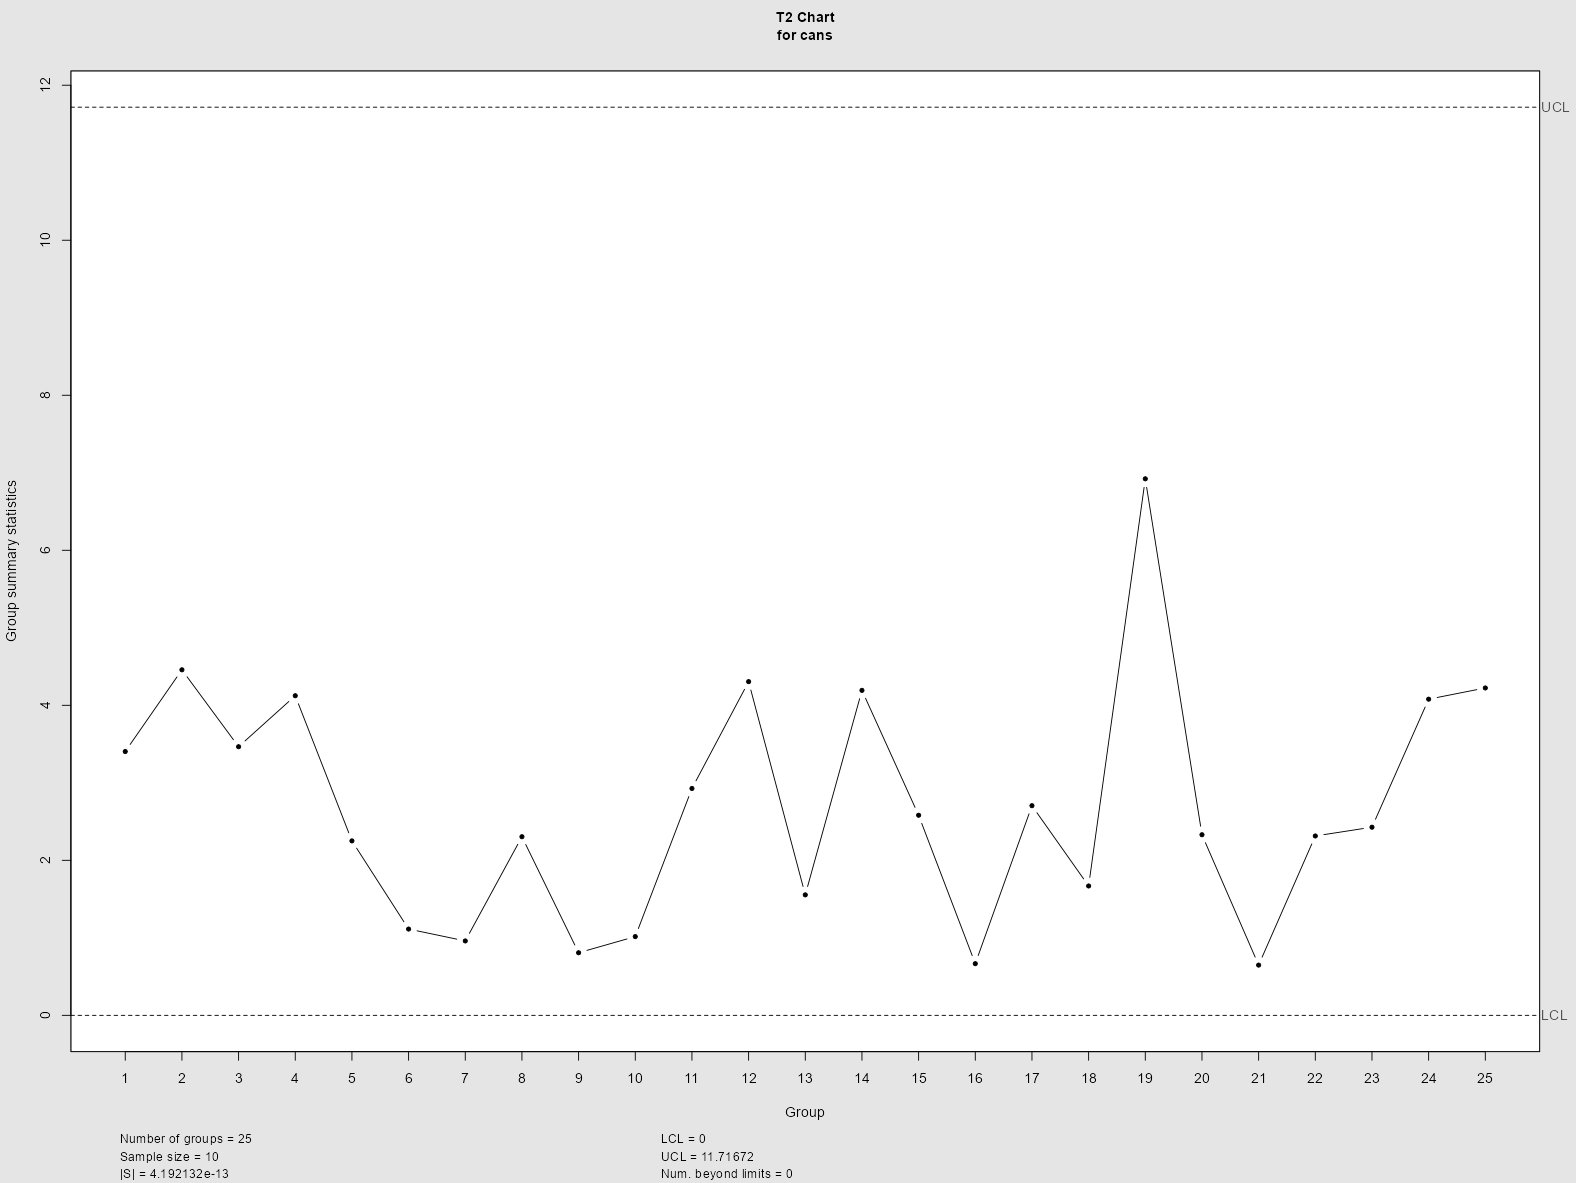

In [6]:
## Use mqcc to Plot the Phase 1 Chart! ##

t2 <- mqcc(cans,type='T2')

Worth noting: `mqcc`'s default $\alpha$ is $1-(1-0.0027)^p$ — exactly the compounded false-alarm-rate correction we derived above, applied automatically for $p=3$ variables.

In [7]:
## Note default alpha = 1 - (1 - 0.0027)^p and in this case p = 3 ##

1 - (0.9973)^3

[1] 0.00807815

`t2` also stores the Phase I mean vector and covariance matrix estimates directly — these are exactly the $\bar{\mathbf{x}}$ and $\mathbf{S}$ we'll need going forward.

In [8]:
## Notice, t2 contains the estimated mean vector and v-cov matrix ##

t2$center

   Line1    Line2    Line3 
12.00030 16.00057 23.99957 

In [9]:
t2$cov

             Line1        Line2        Line3
Line1 9.195855e-05 5.209283e-05 4.552181e-05
Line2 5.209283e-05 1.003213e-04 4.989932e-05
Line3 4.552181e-05 4.989932e-05 9.512286e-05

### Applying the Phase I estimates to Phase II

With no Phase I points out of control, we have good evidence the process is stable and our estimates are solid — time to bring them forward into Phase II. Unlike a univariate Shewhart chart, we don't carry forward the control limit itself; we carry forward the **mean vector and covariance matrix**, and let `mqcc` recompute the appropriate Phase II limit from those.

In [10]:
## Read in Phase II Can Volume Data ##

sn2 <- excel_sheets("Can Volume Phase II Data.xlsx")

cans2 <- lapply(sn2,FUN=function(x){
  
  d <- read_xlsx("Can Volume Phase II Data.xlsx",sheet=x) %>%
    dplyr::select(-`Sample`,-`Line Number`)
  
  return(d)
  
})

names(cans2) <- paste("Line",1:3,sep="")

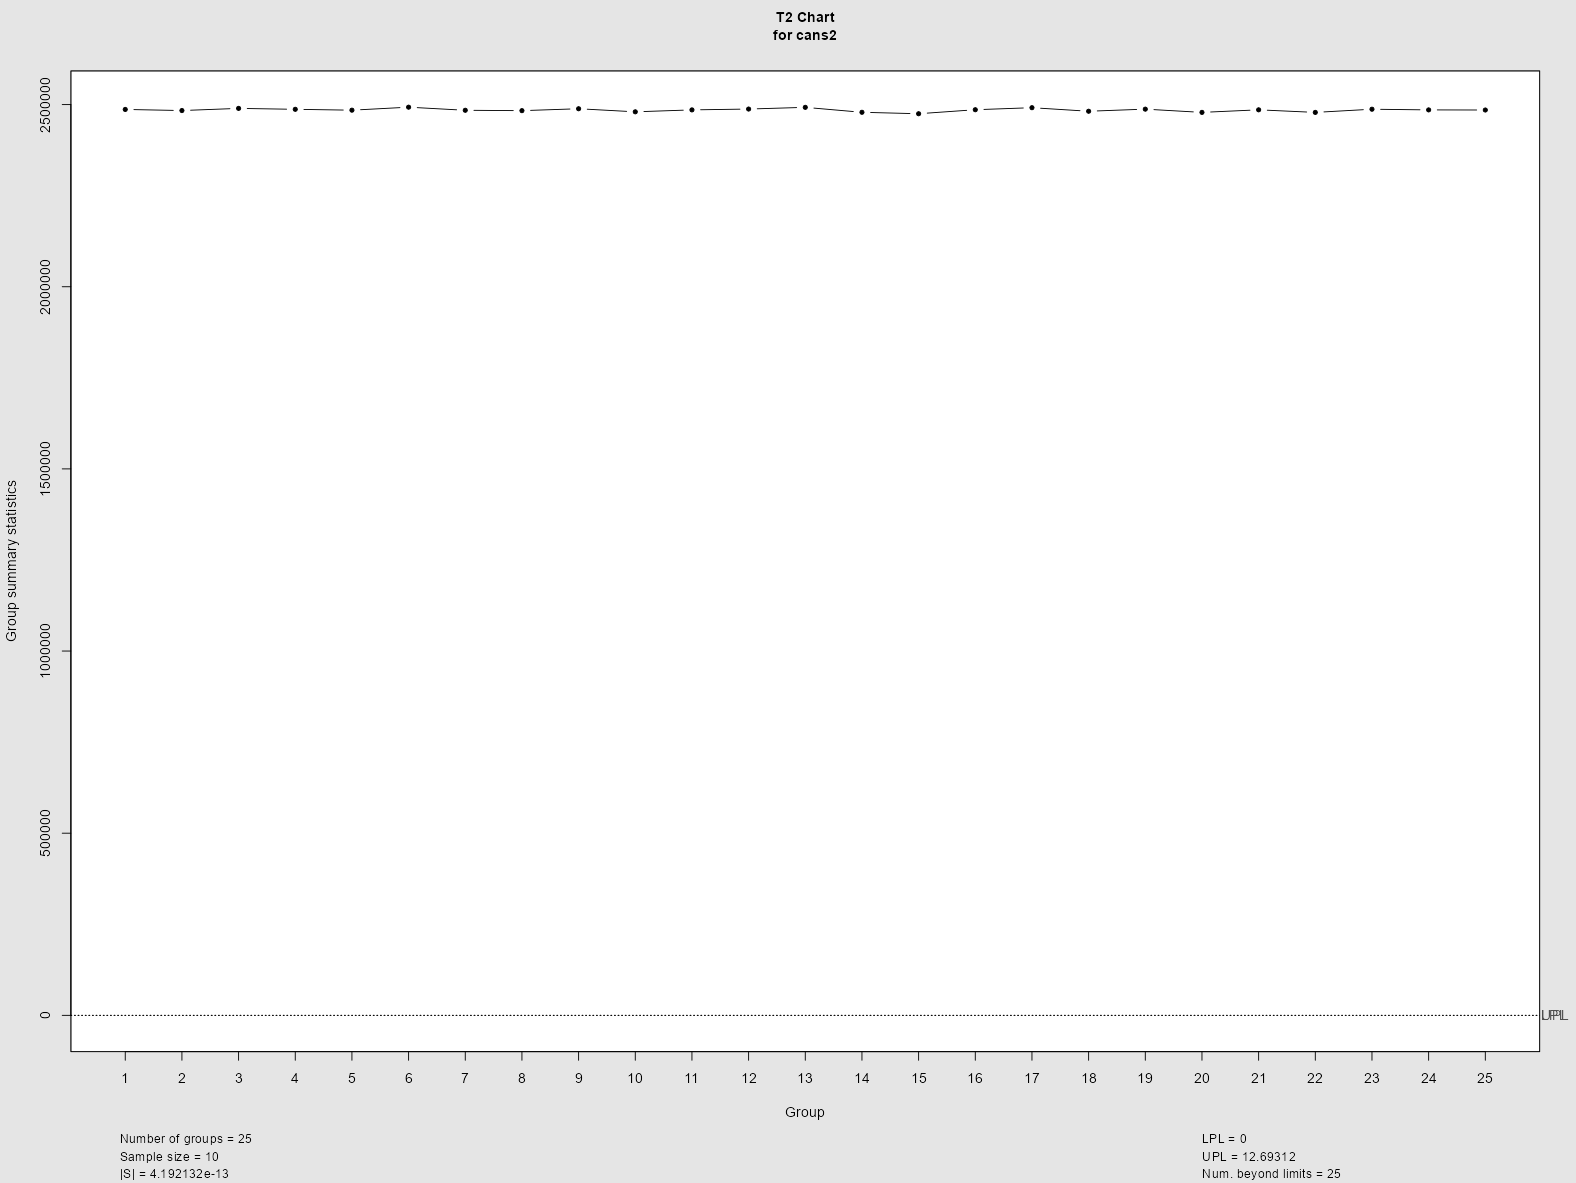

In [11]:
## Use mqcc to Plot the Phase II Chart! ##

p2 <- mqcc(cans2,type="T2",
           center=t2$center,
           cov=t2$cov,
           limits=F,pred.limits=T,
           plot=T)

The process is immediately, unmistakably out of control. So which line is actually the problem?

In [12]:
## We can see the process is way out of control immediately!
## What is the new mean vector? ##

lapply(cans2,FUN=function(x){
  
  return(mean(rowMeans(x)))
  
})

$Line1
[1] 12.00055

$Line2
[1] 16.00012

$Line3
[1] 19.99968


Lines 1 and 2 look fine — Line 3 is the culprit. Interesting wrinkle: even though Line 3's mean **decreased**, our $T^2$ statistic still plots **above** the upper control limit. That's because $T^2$ is strictly non-negative regardless of the direction of the shift — much like the $F$-statistic in ANOVA, it can't tell you *which way* a variable moved, only that *something* has.

## Post-Hoc Analysis: Which Variable Went OOC?

This is exactly like ANOVA in another sense too: after a significant omnibus $F$-test, we typically follow up with post-hoc tests to figure out *which* group differs. Here, our post-hoc analysis is to drop back down to individual $\bar{X}$/$s$ charts for each line, using the Phase I estimates from the $T^2$ analysis.

We'll need the bias correction constant $c_4$ for $n=10$ to convert our covariance-matrix-based variance estimates into unbiased standard deviation estimates, the same way we did for the $\bar{x}$/$s$ chart weeks ago.

In [13]:
## Just like ANOVA, when we have a significant omnibus F-test,
## we generally perform a post-hoc analysis. Here, our post-hoc 
## analysis involves the plotting of individual x-bar & s charts ##

## Let's extract the phase I mean and sd ##

## c4 for n = 10 is 0.9727 ##

c4 <- 0.9727

line1_xbar <- t2$center[1]
line2_xbar <- t2$center[2]
line3_xbar <- t2$center[3]

line1_sd <- sqrt(t2$cov[1,1])/c4
line2_sd <- sqrt(t2$cov[2,2])/c4
line3_sd <- sqrt(t2$cov[3,3])/c4

In [14]:
## Calculate UCL & LCL ##

line1_ucl <- line1_xbar + 3*line1_sd
line1_lcl <- line1_xbar - 3*line1_sd

line2_ucl <- line2_xbar + 3*line2_sd
line2_lcl <- line2_xbar - 3*line2_sd

line3_ucl <- line3_xbar + 3*line3_sd
line3_lcl <- line3_xbar - 3*line3_sd

### Line 1

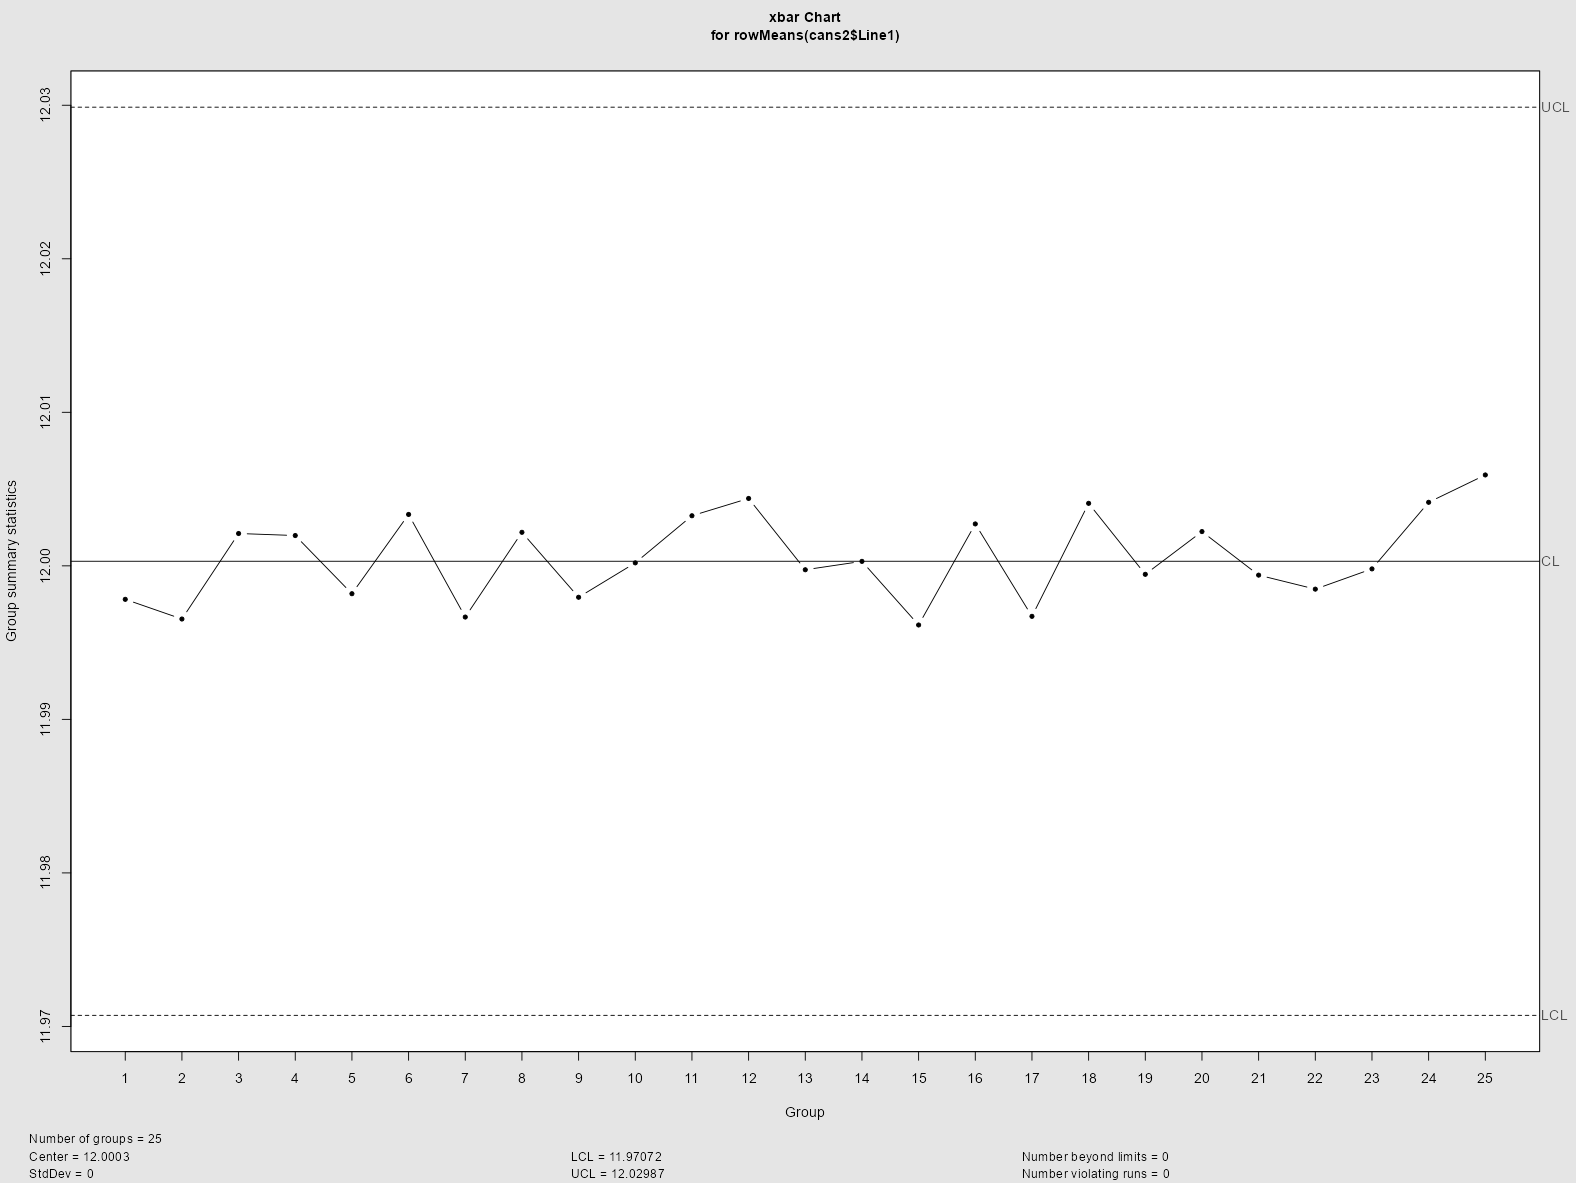

In [15]:
xbar1 <- qcc(rowMeans(cans2$Line1),
             type="xbar",
             center=line1_xbar,
             sigma=line1_sd,
             sizes=10,
             limits=c(line1_lcl,line1_ucl))

### Line 2

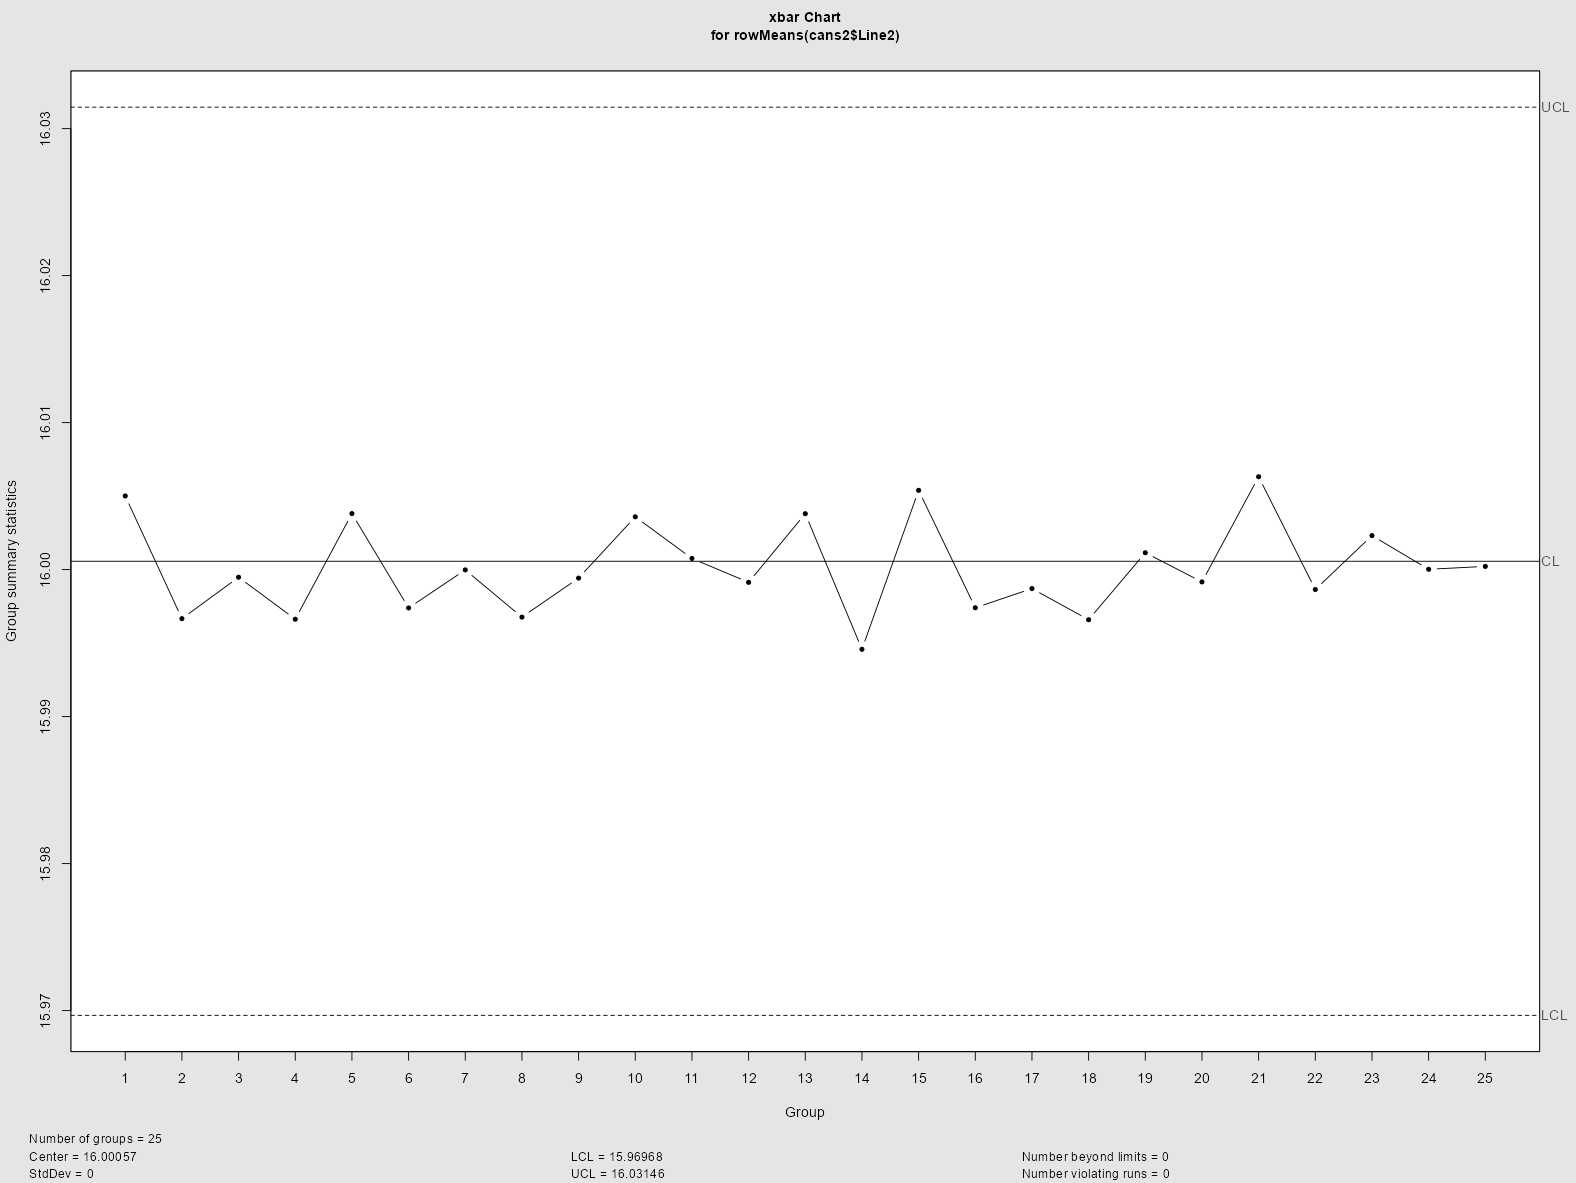

In [16]:
xbar2 <- qcc(rowMeans(cans2$Line2),
             type="xbar",
             center=line2_xbar,
             sigma=line2_sd,
             sizes=10,
             limits=c(line2_lcl,line2_ucl))

### Line 3

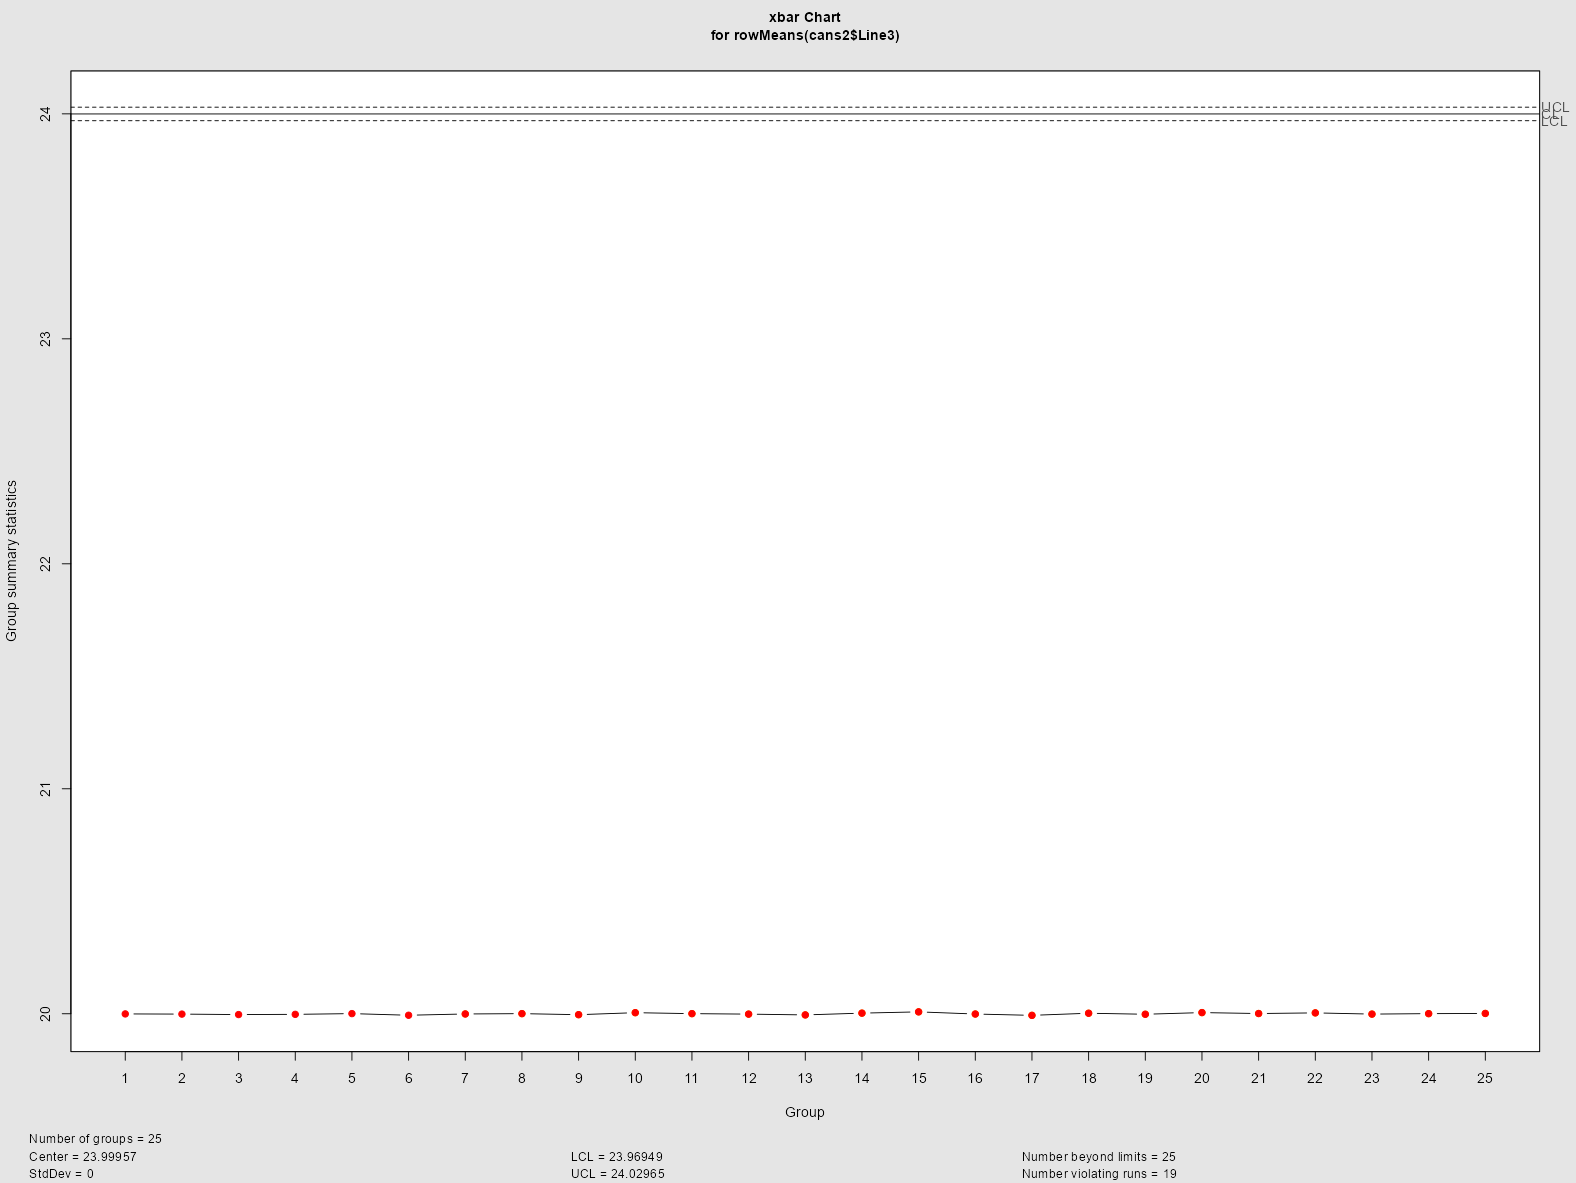

In [17]:
xbar3 <- qcc(rowMeans(cans2$Line3),
             type="xbar",
             center=line3_xbar,
             sigma=line3_sd,
             sizes=10,
             limits=c(line3_lcl,line3_ucl))

If it wasn't already obvious from the $T^2$ chart alone, this makes it unmistakable: **Line 3 is out of control**, while Lines 1 and 2 are behaving normally.

The $T^2$ chart got us to "something is wrong" immediately and efficiently — but like the Shewhart $\bar{X}$ chart it generalizes, it only uses the most recent sample in its plotting statistic. Next notebook, we'll fix that same inefficiency in the multivariate setting the same way we did for univariate charts: with a multivariate EWMA.